### Import Libraries

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

from sklearn.pipeline import Pipeline
from itertools import count

from scipy.stats.mstats import winsorize
import warnings
warnings.filterwarnings('ignore')



### Configuration

In [18]:
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
sns.set_style('darkgrid')

In [19]:
#load data set
df=pd.read_csv('../Breast-Cancer-Diagnosis-Analysis/Data Set/Breast Cancer.csv')
df.head(3)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.990,10.380,122.800,1001.000,0.118,0.278,0.300,0.147,0.242,0.079,1.095,0.905,8.589,153.400,0.006,0.049,0.054,0.016,0.030,0.006,25.380,17.330,184.600,2019.000,0.162,0.666,0.712,0.265,0.460,0.119,NaN
1,842517,M,20.570,17.770,132.900,1326.000,0.085,0.079,0.087,0.070,0.181,0.057,0.543,0.734,3.398,74.080,0.005,0.013,0.019,0.013,0.014,0.004,24.990,23.410,158.800,1956.000,0.124,0.187,0.242,0.186,0.275,0.089,NaN
2,84300903,M,19.690,21.250,130.000,1203.000,0.110,0.160,0.197,0.128,0.207,0.060,0.746,0.787,4.585,94.030,0.006,0.040,0.038,0.021,0.022,0.005,23.570,25.530,152.500,1709.000,0.144,0.424,0.450,0.243,0.361,0.088,NaN


### Data Preprocessing

In [20]:
# drop  unnecessary columns
df.drop(['id','Unnamed: 32'],axis=1,inplace=True)

In [21]:
#encode target variable
df['diagnosis']=df['diagnosis'].map({'M':1,'B':0})

### Exploratory Data Analysis (EDA)

In [22]:
df['diagnosis'].value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

In [23]:
# get like presentage 
df['diagnosis'].value_counts(normalize=True)*100 

diagnosis
0   62.742
1   37.258
Name: proportion, dtype: float64

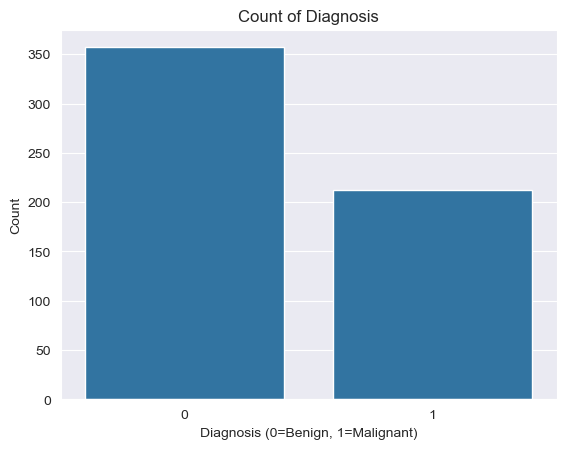

In [24]:
# understand using  count plot value counts
plt.Figure(figsize=(6,4))
sns.countplot(x='diagnosis',data=df)
plt.title('Count of Diagnosis')
plt.xlabel('Diagnosis (0=Benign, 1=Malignant)')
plt.ylabel('Count')
plt.show()

In [25]:
# distribution of features all  columns in
df.describe()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000
mean,0.373,14.127,19.290,91.969,654.889,0.096,0.104,0.089,0.049,0.181,0.063,0.405,1.217,2.866,40.337,0.007,0.025,0.032,0.012,0.021,0.004,16.269,25.677,107.261,880.583,0.132,0.254,0.272,0.115,0.290,0.084
std,0.484,3.524,4.301,24.299,351.914,0.014,0.053,0.080,0.039,0.027,0.007,0.277,0.552,2.022,45.491,0.003,0.018,0.030,0.006,0.008,0.003,4.833,6.146,33.603,569.357,0.023,0.157,0.209,0.066,0.062,0.018
min,0.000,6.981,9.710,43.790,143.500,0.053,0.019,0.000,0.000,0.106,0.050,0.112,0.360,0.757,6.802,0.002,0.002,0.000,0.000,0.008,0.001,7.930,12.020,50.410,185.200,0.071,0.027,0.000,0.000,0.157,0.055
25%,0.000,11.700,16.170,75.170,420.300,0.086,0.065,0.030,0.020,0.162,0.058,0.232,0.834,1.606,17.850,0.005,0.013,0.015,0.008,0.015,0.002,13.010,21.080,84.110,515.300,0.117,0.147,0.115,0.065,0.250,0.071
50%,0.000,13.370,18.840,86.240,551.100,0.096,0.093,0.062,0.034,0.179,0.062,0.324,1.108,2.287,24.530,0.006,0.020,0.026,0.011,0.019,0.003,14.970,25.410,97.660,686.500,0.131,0.212,0.227,0.100,0.282,0.080
75%,1.000,15.780,21.800,104.100,782.700,0.105,0.130,0.131,0.074,0.196,0.066,0.479,1.474,3.357,45.190,0.008,0.032,0.042,0.015,0.023,0.005,18.790,29.720,125.400,1084.000,0.146,0.339,0.383,0.161,0.318,0.092
max,1.000,28.110,39.280,188.500,2501.000,0.163,0.345,0.427,0.201,0.304,0.097,2.873,4.885,21.980,542.200,0.031,0.135,0.396,0.053,0.079,0.030,36.040,49.540,251.200,4254.000,0.223,1.058,1.252,0.291,0.664,0.207


In [27]:
#features and target variable

mean_df=df.groupby('diagnosis').mean().T
mean_df['diff']=abs(mean_df[1]-mean_df[0])

# print top 15 features with highest difference
print('top 15 features with highest difference between malignant and benign:','\n',
      mean_df.sort_values(by='diff',ascending=False).head(15))


top 15 features with highest difference between malignant and benign: 
 diagnosis                  0        1    diff
area_worst           558.899 1422.286 863.387
area_mean            462.790  978.376 515.586
perimeter_worst       87.006  141.370  54.364
area_se               21.135   72.672  51.537
perimeter_mean        78.075  115.365  37.290
radius_worst          13.380   21.135   7.755
texture_worst         23.515   29.318   5.803
radius_mean           12.147   17.463   5.316
texture_mean          17.915   21.605   3.690
perimeter_se           2.000    4.324   2.324
radius_se              0.284    0.609   0.325
concavity_worst        0.166    0.451   0.284
compactness_worst      0.183    0.375   0.192
concavity_mean         0.046    0.161   0.115
concave points_worst   0.074    0.182   0.108


In [28]:
# get top 10 features with highest difference
top_10_features=mean_df.sort_values('diff',ascending=False).head(10).index

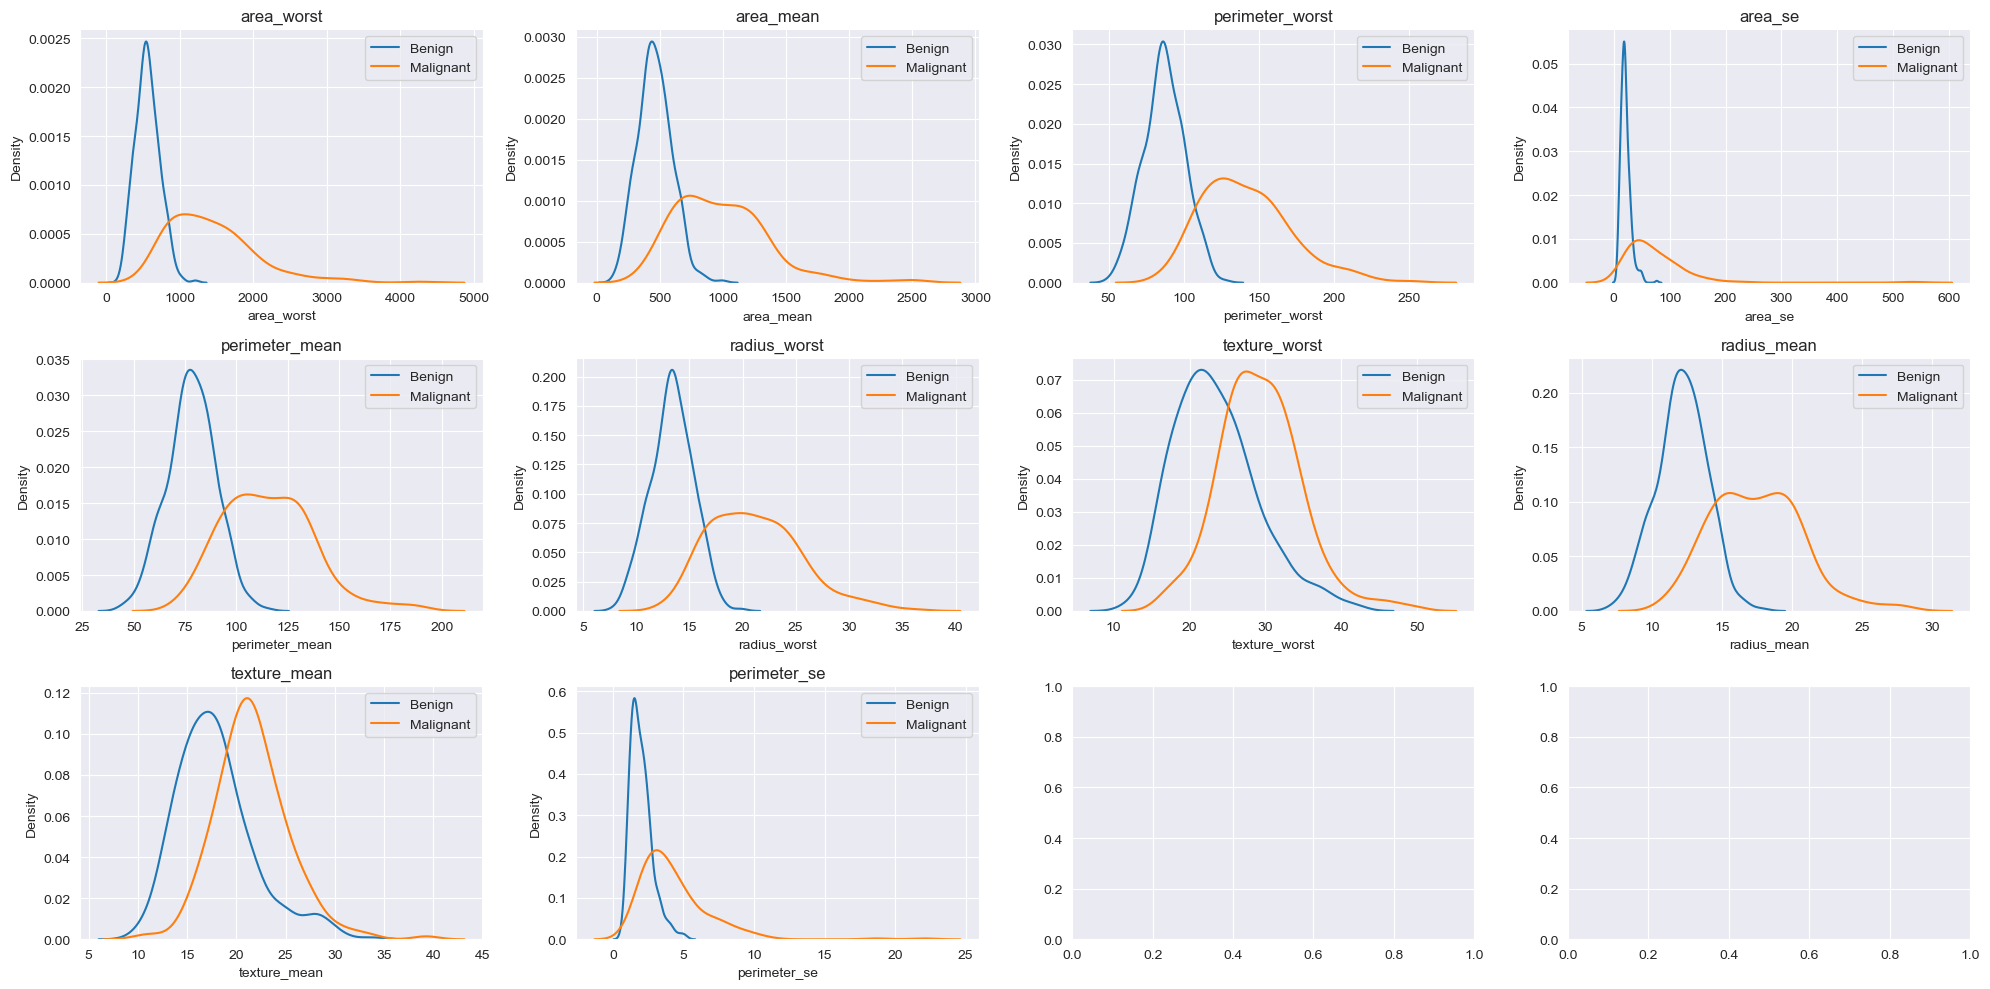

In [30]:
#create kernel density plots for top 10 features

fig,axes=plt.subplots(3,4,figsize=(20,10))
axes=axes.flatten()

for i,col in enumerate(top_10_features):
    sns.kdeplot(df[df['diagnosis']==0][col], ax=axes[i], label='Benign')
    sns.kdeplot(df[df['diagnosis']==1][col], ax=axes[i], label='Malignant')
    axes[i].set_title(col)
    axes[i].legend()
plt.tight_layout()
plt.show()

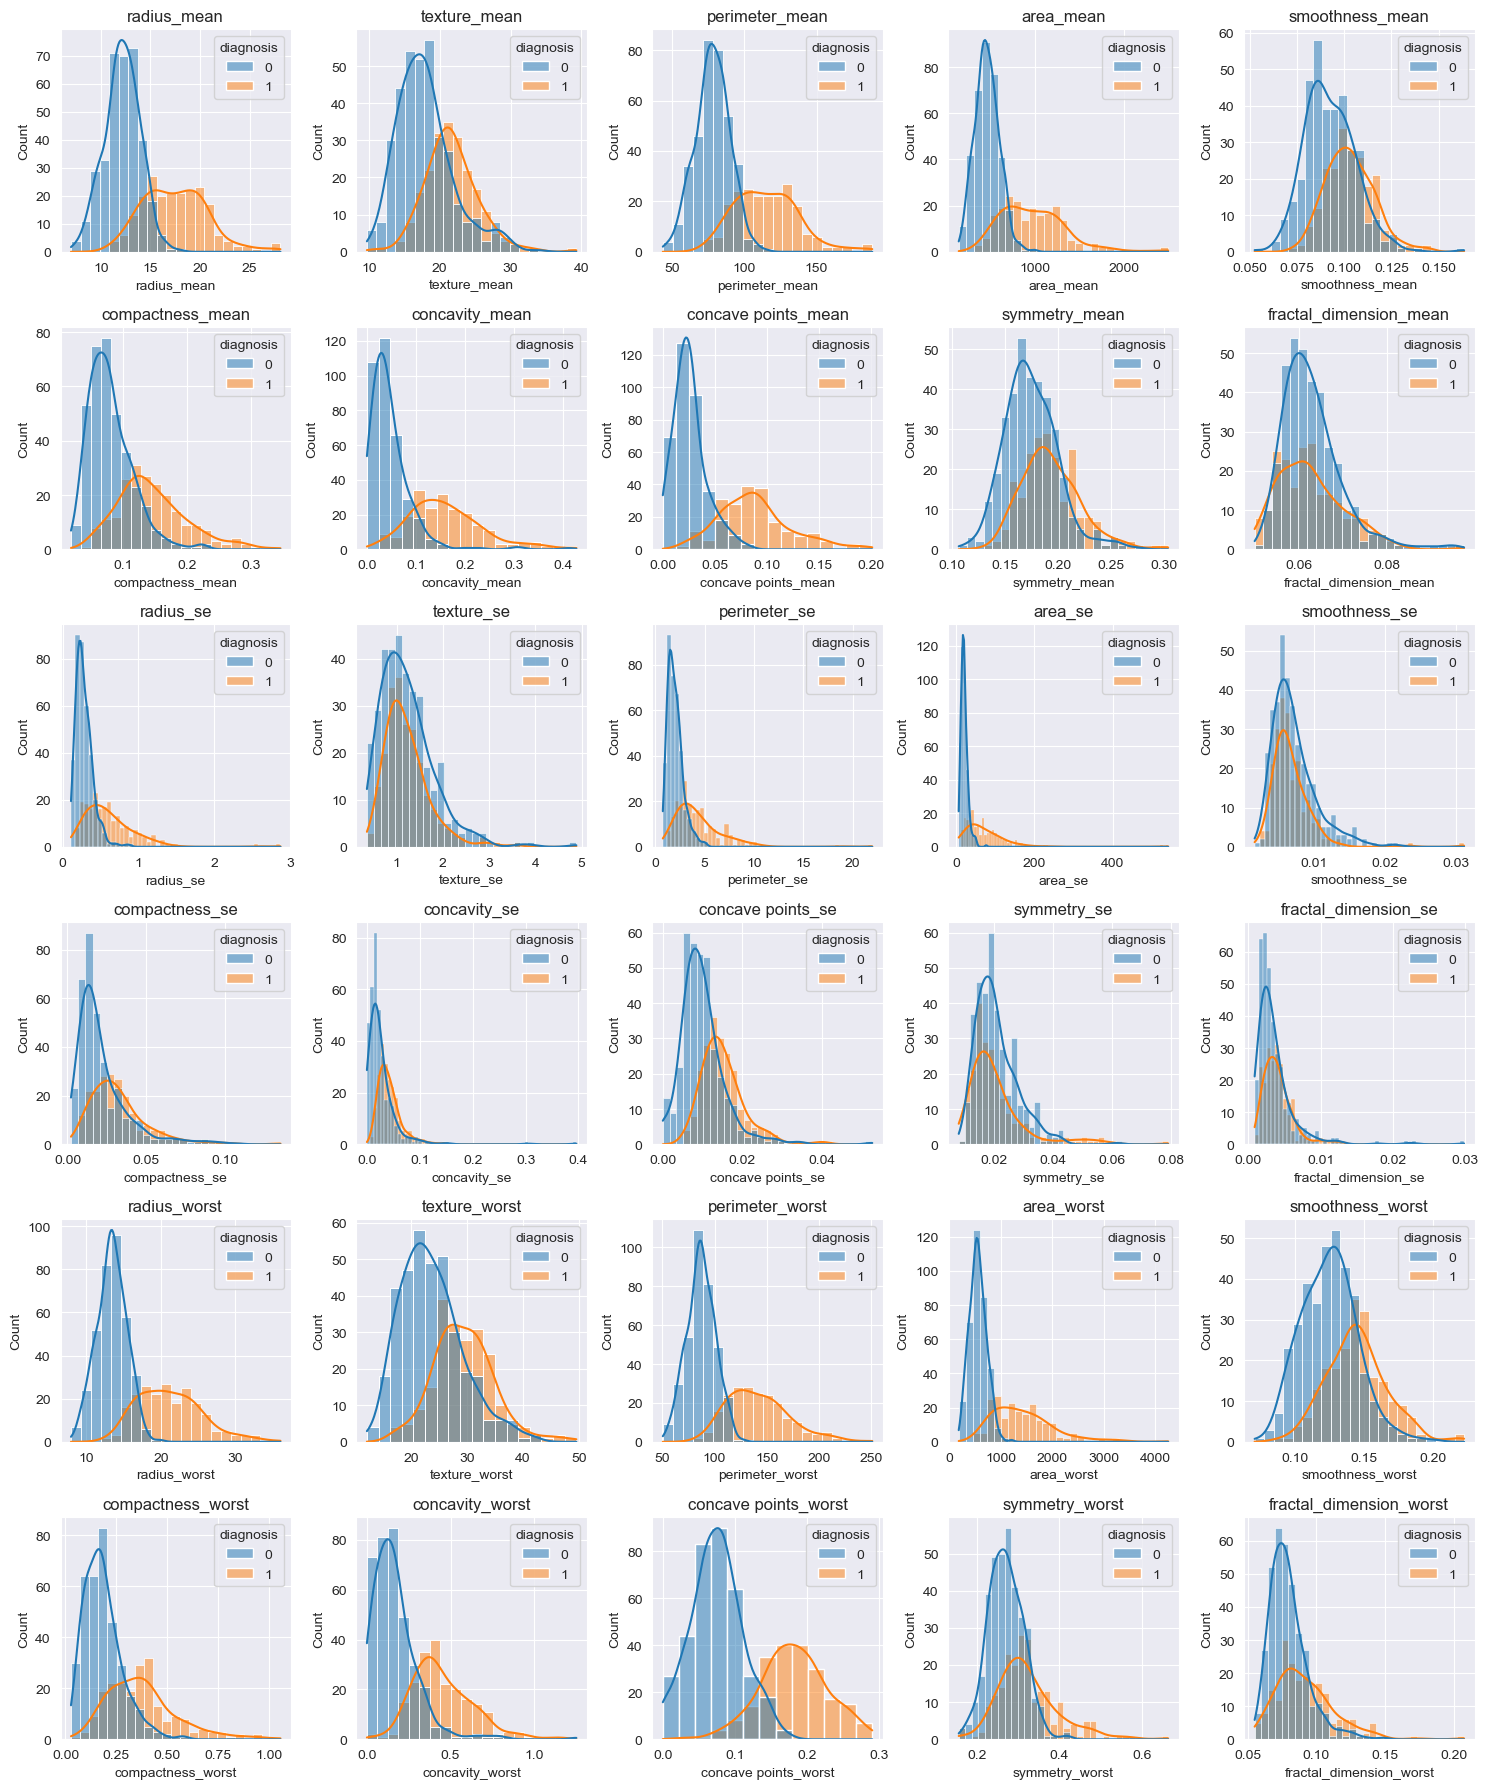

In [31]:
# identify using histogram 
fig, axes= plt.subplots(6,5, figsize=(15,18))
axes=axes.flatten()

for i, col in enumerate(df.columns[1:]):
    sns.histplot(data=df, x=col, hue='diagnosis', ax=axes[i], kde=True)
    axes[i].set_title(col)
plt.tight_layout()
plt.show()


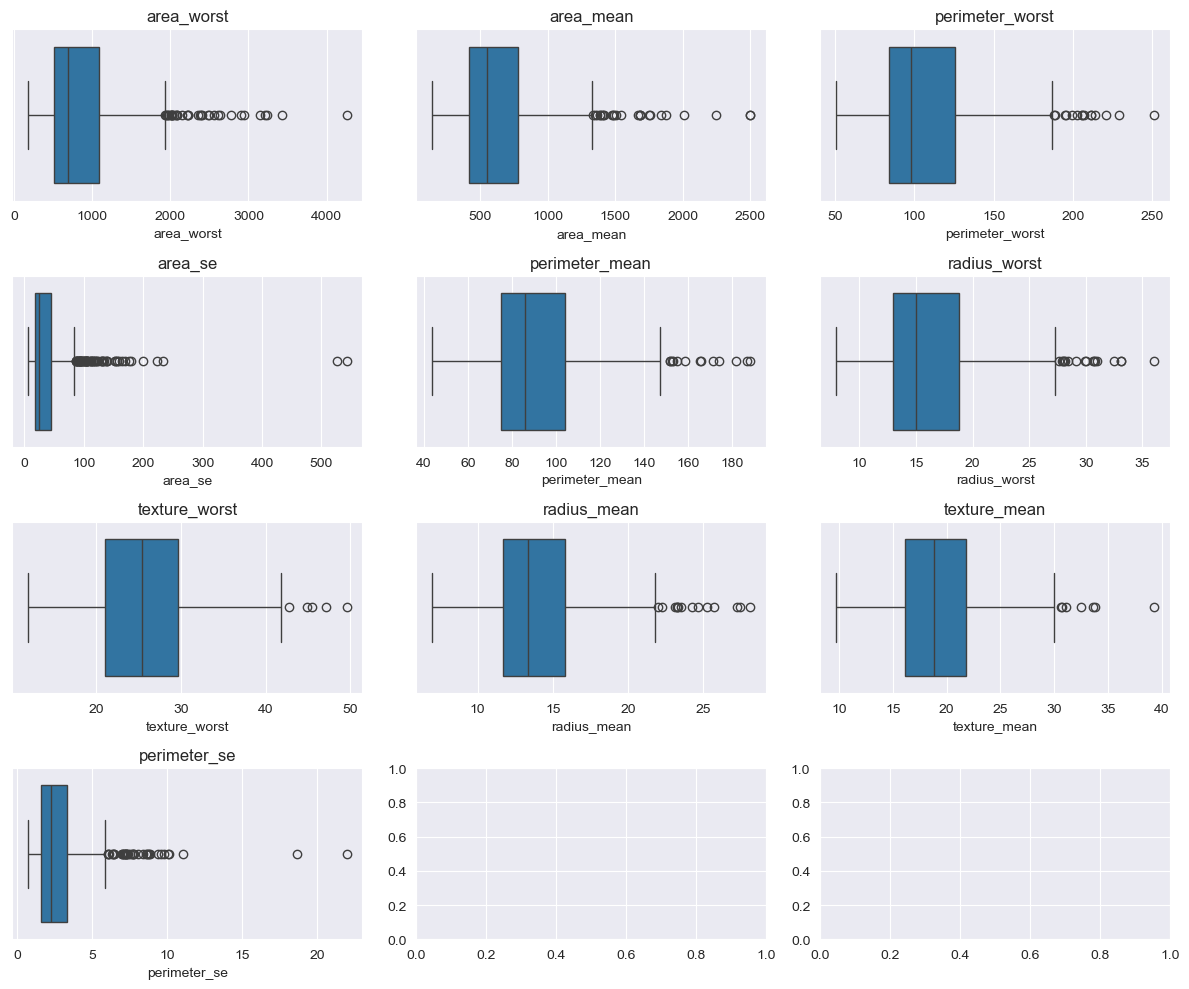

In [33]:
# identify outliers using box plot
fig, axes=plt.subplots(4,3, figsize=(12,10))
axes=axes.flatten()

for i, col in enumerate(top_10_features):
    sns.boxplot(df, x=col, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

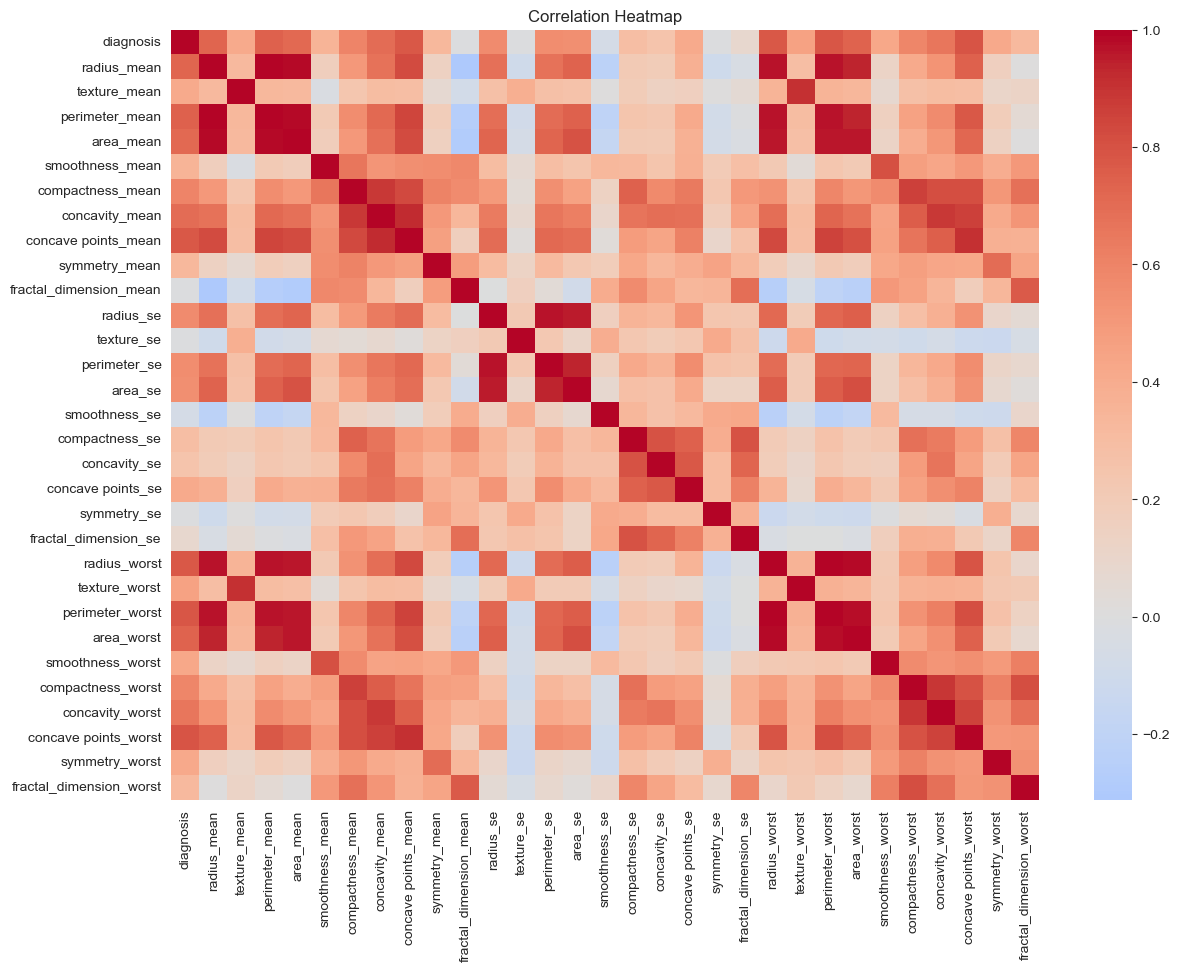

In [34]:
#heat map to identfy corilations 
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

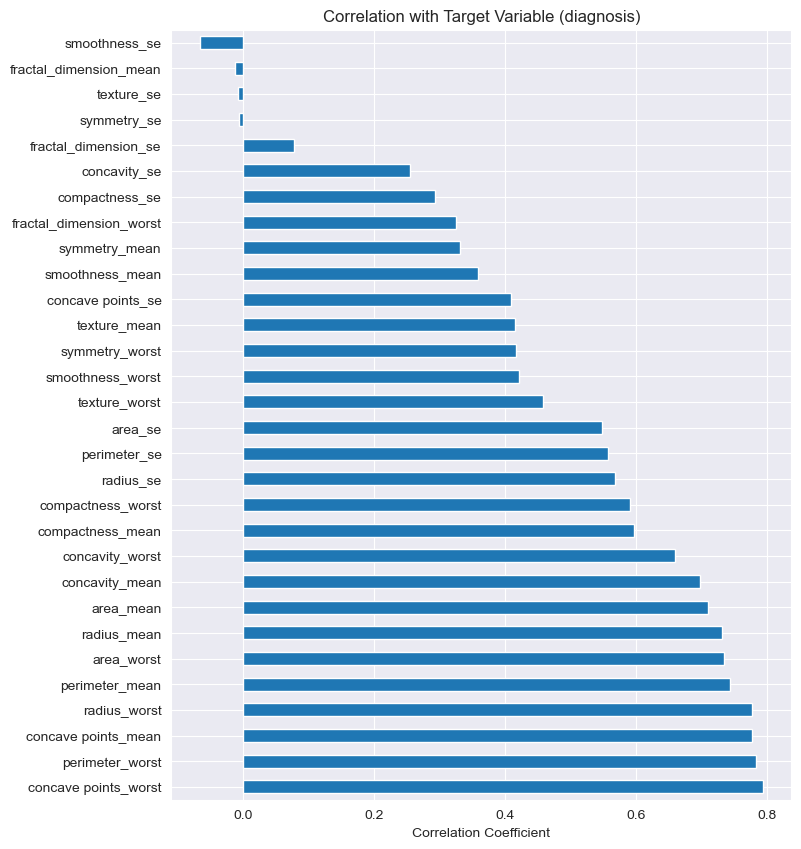

In [35]:
# corilation with corr_target
corr_target=df.corr()['diagnosis'].sort_values(ascending=False)

plt.figure(figsize=(8,10))
corr_target.drop('diagnosis').plot(kind='barh')
plt.title('Correlation with Target Variable (diagnosis)')
plt.xlabel('Correlation Coefficient')
plt.show()

In [36]:
# remove high corilation features 
corr_matrix=df.corr().abs()
corr_matrix


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
diagnosis,1.000,0.730,0.415,0.743,0.709,0.359,0.597,0.696,0.777,0.330,0.013,0.567,0.008,0.556,0.548,0.067,0.293,0.254,0.408,0.007,0.078,0.776,0.457,0.783,0.734,0.421,0.591,0.660,0.794,0.416,0.324
radius_mean,0.730,1.000,0.324,0.998,0.987,0.171,0.506,0.677,0.823,0.148,0.312,0.679,0.097,0.674,0.736,0.223,0.206,0.194,0.376,0.104,0.043,0.970,0.297,0.965,0.941,0.120,0.413,0.527,0.744,0.164,0.007
texture_mean,0.415,0.324,1.000,0.330,0.321,0.023,0.237,0.302,0.293,0.071,0.076,0.276,0.386,0.282,0.260,0.007,0.192,0.143,0.164,0.009,0.054,0.353,0.912,0.358,0.344,0.078,0.278,0.301,0.295,0.105,0.119
perimeter_mean,0.743,0.998,0.330,1.000,0.987,0.207,0.557,0.716,0.851,0.183,0.261,0.692,0.087,0.693,0.745,0.203,0.251,0.228,0.407,0.082,0.006,0.969,0.303,0.970,0.942,0.151,0.456,0.564,0.771,0.189,0.051
area_mean,0.709,0.987,0.321,0.987,1.000,0.177,0.499,0.686,0.823,0.151,0.283,0.733,0.066,0.727,0.800,0.167,0.213,0.208,0.372,0.072,0.020,0.963,0.287,0.959,0.959,0.124,0.390,0.513,0.722,0.144,0.004
smoothness_mean,0.359,0.171,0.023,0.207,0.177,1.000,0.659,0.522,0.554,0.558,0.585,0.301,0.068,0.296,0.247,0.332,0.319,0.248,0.381,0.201,0.284,0.213,0.036,0.239,0.207,0.805,0.472,0.435,0.503,0.394,0.499
compactness_mean,0.597,0.506,0.237,0.557,0.499,0.659,1.000,0.883,0.831,0.603,0.565,0.497,0.046,0.549,0.456,0.135,0.739,0.571,0.642,0.230,0.507,0.535,0.248,0.590,0.510,0.566,0.866,0.816,0.816,0.510,0.687
concavity_mean,0.696,0.677,0.302,0.716,0.686,0.522,0.883,1.000,0.921,0.501,0.337,0.632,0.076,0.660,0.617,0.099,0.670,0.691,0.683,0.178,0.449,0.688,0.300,0.730,0.676,0.449,0.755,0.884,0.861,0.409,0.515
concave points_mean,0.777,0.823,0.293,0.851,0.823,0.554,0.831,0.921,1.000,0.462,0.167,0.698,0.021,0.711,0.690,0.028,0.490,0.439,0.616,0.095,0.258,0.830,0.293,0.856,0.810,0.453,0.667,0.752,0.910,0.376,0.369
symmetry_mean,0.330,0.148,0.071,0.183,0.151,0.558,0.603,0.501,0.462,1.000,0.480,0.303,0.128,0.314,0.224,0.187,0.422,0.343,0.393,0.449,0.332,0.186,0.091,0.219,0.177,0.427,0.473,0.434,0.430,0.700,0.438


### Feature Engineering

In [37]:
# remobe  0.9 > corilation features
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]
print("Features to drop due to high correlation:", to_drop) 

Features to drop due to high correlation: ['perimeter_mean', 'area_mean', 'concave points_mean', 'perimeter_se', 'area_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'concave points_worst']


In [38]:
df.drop(to_drop, axis=1, inplace=True)

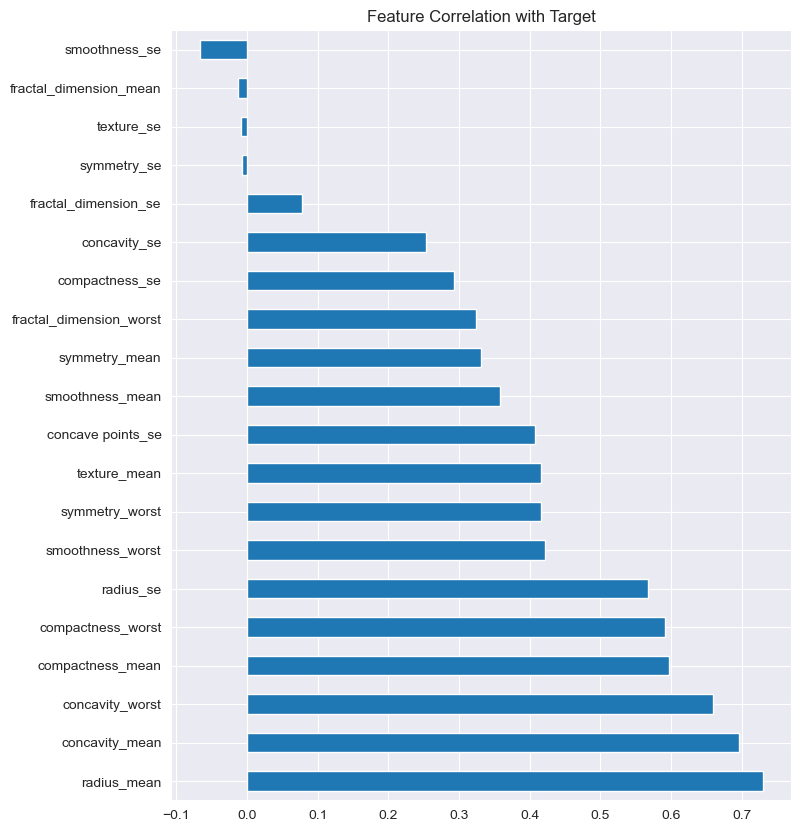

In [39]:
# new shape of data set after removing high corilation features
corr_target = df.corr()['diagnosis'].sort_values(ascending=False)

plt.figure(figsize=(8,10))
corr_target.drop('diagnosis').plot(kind='barh')
plt.title("Feature Correlation with Target")
plt.show()

In [40]:
#winsorize top 10 features to handle outliers
df_winsorized = df.copy()

# romove targe 
num_cols=df_winsorized.drop('diagnosis', axis=1).columns

# apply winsorization to each column
for col in num_cols:
    df_winsorized[col] = winsorize(df_winsorized[col], limits=[0.05, 0.05])

df=df_winsorized.copy()
df.head()

,diagnosis,radius_mean,texture_mean,smoothness_mean,compactness_mean,concavity_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,smoothness_worst,compactness_worst,concavity_worst,symmetry_worst,fractal_dimension_worst
0,1,17.990,13.080,0.118,0.209,0.244,0.231,0.076,0.962,0.905,0.006,0.049,0.054,0.016,0.030,0.006,0.162,0.565,0.683,0.407,0.119
1,1,20.570,17.770,0.085,0.079,0.087,0.181,0.057,0.543,0.734,0.005,0.013,0.019,0.013,0.014,0.004,0.124,0.187,0.242,0.275,0.089
2,1,19.690,21.250,0.110,0.160,0.197,0.207,0.060,0.746,0.787,0.006,0.040,0.038,0.021,0.022,0.005,0.144,0.424,0.450,0.361,0.088
3,1,11.420,20.380,0.119,0.209,0.241,0.231,0.076,0.496,1.156,0.009,0.061,0.057,0.019,0.035,0.008,0.172,0.565,0.683,0.407,0.120
4,1,20.290,14.340,0.100,0.133,0.198,0.181,0.059,0.757,0.781,0.011,0.025,0.057,0.019,0.018,0.005,0.137,0.205,0.400,0.236,0.077


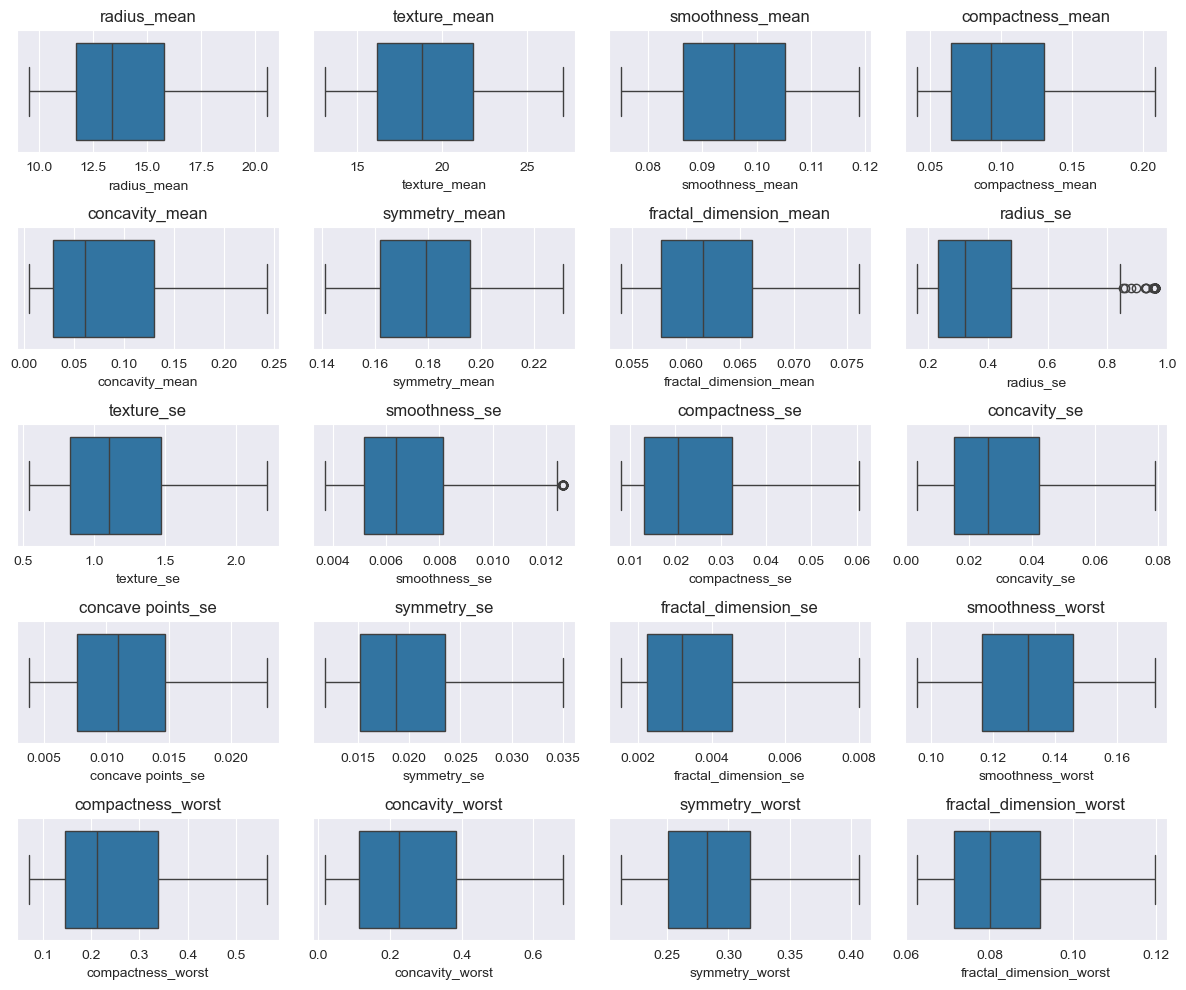

In [41]:
cols = df.drop('diagnosis', axis=1).columns

fig, axes = plt.subplots(5, 4, figsize=(12,10))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

### model buiding 

In [42]:
# split data into features and target variable
x=df.drop('diagnosis', axis=1)
y=df['diagnosis']

In [43]:
# train test split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [44]:
# scale features
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

### Baseline Model

In [45]:
model_logistic=LogisticRegression()
model_logistic.fit(x_train_scaled,y_train)

LogisticRegression()

In [46]:
# print train & test accuracy
print("Train Accuracy:", model_logistic.score(x_train_scaled, y_train))
print("Test Accuracy:", model_logistic.score(x_test_scaled, y_test))

Train Accuracy: 0.9824175824175824
Test Accuracy: 0.9824561403508771


### Model Optimization (Pipeline + GridSearch)

In [47]:
# create pipline 
pipline =Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA()),
    ('model',SVC(kernel='rbf'))

])

In [48]:
#grid search for hyperparameter tuning
param_grid = {
    'pca__n_components': [10,15, 20, 25, 30] ,
    'model__C': [0.1, 1, 10, 100, 1000],
    'model__gamma': [0.001,0.01, 0.1, 1, 'scale']
}

In [49]:
# cross validation
k=5
skf=StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

In [50]:
#hiperparameter tuning using grid search
grid_serch=GridSearchCV(
    pipline,
    param_grid=param_grid,
    scoring='recall',
    cv=skf,
    n_jobs=1,

)

In [51]:
#Grid search fit
grid_serch.fit(x_train,y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('pca', PCA()), ('model', SVC())]),
             n_jobs=1,
             param_grid={'model__C': [0.1, 1, 10, 100, 1000],
                         'model__gamma': [0.001, 0.01, 0.1, 1, 'scale'],
                         'pca__n_components': [10, 15, 20, 25, 30]},
             scoring='recall')

In [52]:
# BEST PARAMETER
print("Best Parameters:", grid_serch.best_params_)


Best Parameters: {'model__C': 10, 'model__gamma': 'scale', 'pca__n_components': 15}


### Model Evaluation

In [56]:
# best model with best parameters
best_model=grid_serch.best_estimator_

# evaluate best model on test set
best_model.fit(x_train,y_train)

y_train_pred=best_model.predict(x_train)
y_test_pred=best_model.predict(x_test)

print('\nTrain Accuracy:', accuracy_score(y_train, y_train_pred))
print('Test Accuracy:', accuracy_score(y_test, y_test_pred))


Train Accuracy: 0.9956043956043956
Test Accuracy: 0.9736842105263158
